# DQN with BIS Error + Delta BIS Error (Direct State Representation)

Deep Q-Network using raw BIS_ERROR and DELTA_BIS_ERROR values as input features (2 features).

In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque
import random
from pathlib import Path
import matplotlib.pyplot as plt

from utils.eval_metrics import (
    calculate_bis_metrics,
    get_age_group,
    create_results_dataframe,
    create_summary_by_age_group,
    save_evaluation_results,
)

# ============================================================================
# TRAINING CONFIGURATION
# ============================================================================

EPISODES = 1000
STEPS_PER_EPISODE = 720
BATCH_SIZE = 64
GAMMA = 0.69
LR = 1e-3
EPSILON_START = 1.0
EPSILON_END = 0.01
EPSILON_DECAY = 0.995
REPLAY_CAPACITY = 100_000
TARGET_UPDATE_FREQ = 10

# ============================================================================
# PK/PD SIMULATION CONFIG
# ============================================================================

INTEGRATION_DT_SECONDS = 1.0
DT = INTEGRATION_DT_SECONDS / 60.0
SIMULATION_STEP_SECONDS = 5.0
SIMULATION_STEP_SUBSTEPS = max(1, int(SIMULATION_STEP_SECONDS / INTEGRATION_DT_SECONDS))

# ============================================================================
# PK/PD PARAMETERS (Schnider Model)
# ============================================================================

V1 = 4.27
K10, K12, K13 = 0.119, 0.112, 0.042
K21, K31 = 0.055, 0.0033
KE0 = 0.17
E0, EMAX, EC50, HILL_PD = 97.4, 97.4, 3.4, 1.89
BIS_TARGET = 50.0
BIS_TARGET_RANGE = (40, 60)

# ============================================================================
# RL CONFIGURATION (Direct state: BIS_ERROR + DELTA_BIS)
# ============================================================================

ACTIONS = list(np.linspace(0.0, 6.0, 15))
NUM_ACTIONS = len(ACTIONS)
N_FEATURES = 2  # BIS_ERROR and DELTA_BIS

BIS_ERROR_MIN, BIS_ERROR_MAX = -50.0, 50.0
DELTA_BIS_MIN, DELTA_BIS_MAX = -30.0, 30.0

# ============================================================================
# EVALUATION CONFIGURATION
# ============================================================================

EVAL_SAMPLE_SIZE = 500
EVAL_EPISODE_LENGTHS = [300, 600, 1200, 3600]
RANDOM_SEED = 42

AGE_GROUPS = {
    "25-29": (25, 29),
    "30-45": (30, 45),
    "46-60": (46, 60),
    "60-80": (60, 80),
    "80+": (80, 120),
}

# ============================================================================
# PATHS
# ============================================================================

ARTIFACTS_DIR = Path("artifacts")
METRICS_DIR = Path("metrics")
DATA_PATH = Path("data/Patients Data.csv")
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
METRICS_DIR.mkdir(parents=True, exist_ok=True)
DQN_PATH = ARTIFACTS_DIR / "dqn_bis_delta_bis_error_network.pth"

# ============================================================================
# DATA LOADING AND PREPROCESSING
# ============================================================================

def load_data(path):
    return pd.read_csv(path)


def preprocess_data(df):
    df = df.copy()

    def parse_age(x):
        try:
            parts = str(x).strip().split(" ")
            if len(parts) < 2:
                return 50
            low = int(parts[1])
            if len(parts) > 3:
                high = 100 if parts[3] == "older" else int(parts[3])
                return int(random.randrange(low, high))
            return int(low)
        except Exception:
            return 50

    if "AgeCategory" in df.columns:
        df.loc[:, "AgeCategory"] = df["AgeCategory"].apply(parse_age)
    return df


def schnider_model(age, weight, height, sex):
    sex = str(sex).lower()
    if sex == "male":
        lbm = 1.10 * weight - 128 * (weight**2) / (height**2)
    else:
        lbm = 1.07 * weight - 148 * (weight**2) / (height**2)

    V1_s = 4.27
    V2_s = 18.9 - 0.391 * (age - 53)

    k10_s = 0.443 + 0.0107 * (weight - 77) - 0.0159 * (lbm - 59) + 0.0062 * (height - 177)
    k12_s = 0.302 - 0.0056 * (age - 53)
    k13_s = 0.196
    k21_s = (1.29 - 0.024 * (age - 53)) / V2_s
    k31_s = 0.0035
    ke0_s = 0.456

    A = np.array(
        [
            [-(k10_s + k12_s + k13_s), k21_s, k31_s, 0],
            [k12_s, -k21_s, 0, 0],
            [k13_s, 0, -k31_s, 0],
            [ke0_s, 0, 0, -ke0_s],
        ],
        dtype=float,
    )
    B = np.array([[1 / V1_s], [0], [0], [0]], dtype=float)
    return {"A": A, "B": B}


def generate_schnider_dataset(df):
    params_list = []
    for _, row in df.iterrows():
        params = schnider_model(
            age=row["AgeCategory"],
            weight=row["WeightInKilograms"],
            height=row["HeightInMeters"],
            sex=row["Sex"],
        )
        params_list.append(params)

    params_df = pd.DataFrame(params_list)
    return pd.concat([df.reset_index(drop=True), params_df], axis=1)

# ============================================================================
# STATE HELPER FUNCTIONS (Direct representation)
# ============================================================================

def get_state(bis_error, delta_bis_error):
    """Return raw BIS_ERROR and DELTA_BIS as state."""
    error = np.clip(bis_error, BIS_ERROR_MIN, BIS_ERROR_MAX) / BIS_ERROR_MAX
    delta = np.clip(delta_bis_error, DELTA_BIS_MIN, DELTA_BIS_MAX) / DELTA_BIS_MAX
    return np.array([error, delta], dtype=np.float32)


def compute_reward(bis_error, delta_bis_error):
    """Same reward function as DP notebook."""
    if bis_error>10:
        return -0.5(abs(bis_error)-delta_bis_error)
    elif bis_error<-10:
        return -0.5(abs(bis_error)+delta_bis_error)
    else:
        return 1.0/(1.0+abs(bis_error)*abs(delta_bis_error))

# ============================================================================
# DQN NEURAL NETWORK
# ============================================================================

class DQN(nn.Module):
    """Q-Network that takes 2 features (BIS_ERROR, DELTA_BIS) and outputs Q-values."""
    
    def __init__(self, input_dim=N_FEATURES, hidden_dim=128, output_dim=NUM_ACTIONS):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, output_dim),
        )
    
    def forward(self, x):
        return self.net(x)


# ============================================================================
# REPLAY BUFFER
# ============================================================================

class ReplayBuffer:
    def __init__(self, capacity=REPLAY_CAPACITY):
        self.buffer = deque(maxlen=capacity)
    
    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))
    
    def sample(self, batch_size):
        batch = random.sample(self.buffer, min(batch_size, len(self.buffer)))
        states, actions, rewards, next_states, dones = zip(*batch)
        return (
            torch.tensor(np.array(states), dtype=torch.float32),
            torch.tensor(actions, dtype=torch.long),
            torch.tensor(rewards, dtype=torch.float32),
            torch.tensor(np.array(next_states), dtype=torch.float32),
            torch.tensor(dones, dtype=torch.float32),
        )
    
    def __len__(self):
        return len(self.buffer)

# ============================================================================
# DQN AGENT
# ============================================================================

class DQNAgent:
    def __init__(self, lr=LR, gamma=GAMMA, epsilon=EPSILON_START):
        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_end = EPSILON_END
        self.epsilon_decay = EPSILON_DECAY
        
        self.q_network = DQN()
        self.target_network = DQN()
        self.target_network.load_state_dict(self.q_network.state_dict())
        
        self.optimizer = optim.Adam(self.q_network.parameters(), lr=lr)
        self.replay_buffer = ReplayBuffer()
        self.update_step = 0
    
    def select_action(self, state, training=True):
        """Epsilon-greedy action selection."""
        if training and random.random() < self.epsilon:
            return random.randint(0, NUM_ACTIONS - 1)
        with torch.no_grad():
            state_tensor = torch.tensor(state, dtype=torch.float32).unsqueeze(0)
            q_values = self.q_network(state_tensor)
            return q_values.argmax(dim=1).item()
    
    def decay_epsilon(self):
        self.epsilon = max(self.epsilon_end, self.epsilon * self.epsilon_decay)
    
    def store_transition(self, state, action, reward, next_state, done):
        self.replay_buffer.push(state, action, reward, next_state, done)
    
    def update(self, batch_size=BATCH_SIZE):
        if len(self.replay_buffer) < batch_size:
            return 0.0
        
        states, actions, rewards, next_states, dones = self.replay_buffer.sample(batch_size)
        
        current_q = self.q_network(states).gather(1, actions.unsqueeze(1)).squeeze(1)
        with torch.no_grad():
            next_q = self.target_network(next_states).max(1)[0]
            target_q = rewards + self.gamma * next_q * (1 - dones)
        
        loss = nn.MSELoss()(current_q, target_q)
        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.q_network.parameters(), 1.0)
        self.optimizer.step()
        
        self.update_step += 1
        if self.update_step % TARGET_UPDATE_FREQ == 0:
            self.target_network.load_state_dict(self.q_network.state_dict())
        
        return loss.item()

# ============================================================================
# DQN EVALUATOR
# ============================================================================

class DQNEvaluator:
    def __init__(self, agent):
        self.agent = agent
        self.target = BIS_TARGET
    
    def simulate(self, patient_row, duration_seconds):
        duration_steps = max(1, int(duration_seconds / SIMULATION_STEP_SECONDS))
        A = np.asarray(patient_row["A"], dtype=float)
        B = np.asarray(patient_row["B"], dtype=float)
        x = np.zeros((4, 1), dtype=float)

        bis_log = []
        prev_error = 0.0
        last_action_idx = 0

        for step in range(duration_steps):
            ce = np.clip(float(x[3, 0]), 0.0, 10.0)
            ce_h = np.power(ce, HILL_PD)
            ec50_h = np.power(EC50, HILL_PD)

            if ce_h + ec50_h > 0:
                bis_ideal = E0 - EMAX * (ce_h / (ce_h + ec50_h))
            else:
                bis_ideal = E0

            measured_bis = np.clip(float(bis_ideal) + np.random.normal(0, 3), 0, 100)
            error = np.clip(float(measured_bis - self.target), BIS_ERROR_MIN, BIS_ERROR_MAX)
            derr = np.clip(float(error - prev_error), DELTA_BIS_MIN, DELTA_BIS_MAX)

            state = get_state(error, derr)
            if step % 2 == 0:
                last_action_idx = self.agent.select_action(state, training=False)

            u = ACTIONS[last_action_idx]
            for _ in range(SIMULATION_STEP_SUBSTEPS):
                x_dot = A @ x + B * u
                x = x + x_dot * DT
            x = np.clip(x, -10.0, 10.0)

            bis_log.append(float(measured_bis))
            prev_error = error

        return np.array(bis_log)

# TRAINING: DQN Agent

In [ ]:
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

print("=" * 70)
print("DQN with Direct BIS Error + Delta BIS")
print("=" * 70)

agent = DQNAgent(lr=LR, gamma=GAMMA, epsilon=EPSILON_START)
episode_rewards = []
episode_losses = []

print("\nStarting training...")
for ep in range(EPISODES):
    target = np.random.uniform(*BIS_TARGET_RANGE)
    c0 = np.random.uniform(0.5, 4.0)
    x = np.array([[c0], [c0 * 0.3], [c0 * 0.1], [c0 * 0.5]], dtype=float)

    err_prev = 0.0
    derr_prev = 0.0
    ep_reward = 0.0
    ep_loss = 0.0
    loss_count = 0

    for step in range(STEPS_PER_EPISODE):
        ce = np.clip(float(x[3, 0]), 0.0, 10.0)
        ce_h = np.power(ce, HILL_PD)
        ec50_h = np.power(EC50, HILL_PD)

        if ce_h + ec50_h > 0:
            bis_ideal = E0 - EMAX * (ce_h / (ce_h + ec50_h))
        else:
            bis_ideal = E0

        measured_bis = np.clip(float(bis_ideal) + np.random.normal(0, 3), 0, 100)
        error = np.clip(float(measured_bis - target), BIS_ERROR_MIN, BIS_ERROR_MAX)
        derr = np.clip(float(error - err_prev), DELTA_BIS_MIN, DELTA_BIS_MAX)

        state = get_state(error, derr)
        action_idx = agent.select_action(state, training=True)
        u = ACTIONS[action_idx]

        for _ in range(SIMULATION_STEP_SUBSTEPS):
            x_dot = np.array([
                [-(K10 + K12 + K13) * x[0, 0] + K21 * x[1, 0] + K31 * x[2, 0] + (u / V1)],
                [K12 * x[0, 0] - K21 * x[1, 0]],
                [K13 * x[0, 0] - K31 * x[2, 0]],
                [KE0 * (x[0, 0] - x[3, 0])],
            ])
            x = x + x_dot * DT
        x = np.clip(x, -10.0, 10.0)

        next_ce = np.clip(float(x[3, 0]), 0.0, 10.0)
        next_ce_h = np.power(next_ce, HILL_PD)
        next_bis = E0 - EMAX * (next_ce_h / (next_ce_h + ec50_h)) if next_ce_h + ec50_h > 0 else E0
        next_error = float(next_bis - target)
        next_derr = np.clip(next_error - error, DELTA_BIS_MIN, DELTA_BIS_MAX)
        next_state = get_state(next_error, next_derr)
        
        reward = compute_reward(error, derr)
        done = step == STEPS_PER_EPISODE - 1

        agent.store_transition(state, action_idx, reward, next_state, done)
        loss = agent.update()
        if loss > 0:
            ep_loss += loss
            loss_count += 1

        ep_reward += reward
        err_prev = error
        derr_prev = derr

    agent.decay_epsilon()
    episode_rewards.append(ep_reward)
    episode_losses.append(ep_loss / max(loss_count, 1))

    if (ep + 1) % 10 == 0:
        avg_reward = np.mean(episode_rewards[-10:])
        avg_loss = np.mean(episode_losses[-10:])
        print(f"Episode {ep + 1}/{EPISODES} | Avg Reward: {avg_reward:.2f} | Avg Loss: {avg_loss:.4f} | Epsilon: {agent.epsilon:.4f}")

print("\nTraining complete!")

print(f"\nSaving trained agent to {DQN_PATH}...")
torch.save({
    'q_network': agent.q_network.state_dict(),
    'target_network': agent.target_network.state_dict(),
    'epsilon': agent.epsilon,
    'actions': ACTIONS,
}, DQN_PATH)
print("Agent saved successfully!")

print("\nPlotting BIS trajectory...")
target = 50.0
c0 = 2.0
x = np.array([[c0], [c0 * 0.3], [c0 * 0.1], [c0 * 0.5]], dtype=float)
bis_log = []
action_log = []
err_prev = 0.0

for step in range(STEPS_PER_EPISODE):
    ce = np.clip(float(x[3, 0]), 0.0, 10.0)
    ce_h = np.power(ce, HILL_PD)
    ec50_h = np.power(EC50, HILL_PD)
    bis_ideal = E0 - EMAX * (ce_h / (ce_h + ec50_h)) if ce_h + ec50_h > 0 else E0
    measured_bis = np.clip(float(bis_ideal) + np.random.normal(0, 1), 0, 100)
    error = float(measured_bis - target)
    derr = float(error - err_prev)
    state = get_state(error, derr)
    action_idx = agent.select_action(state, training=False)
    u = ACTIONS[action_idx]
    
    for _ in range(SIMULATION_STEP_SUBSTEPS):
        x_dot = np.array([
            [-(K10 + K12 + K13) * x[0, 0] + K21 * x[1, 0] + K31 * x[2, 0] + (u / V1)],
            [K12 * x[0, 0] - K21 * x[1, 0]],
            [K13 * x[0, 0] - K31 * x[2, 0]],
            [KE0 * (x[0, 0] - x[3, 0])],
        ])
        x = x + x_dot * DT
    x = np.clip(x, -10.0, 10.0)
    bis_log.append(measured_bis)
    action_log.append(u)
    err_prev = error

plt.figure(figsize=(14, 4))
plt.subplot(1, 3, 1)
plt.plot(episode_rewards)
plt.title('Episode Rewards')
plt.xlabel('Episode')
plt.ylabel('Reward')
plt.grid(True)
    
plt.subplot(1, 3, 2)
plt.plot(episode_losses)
plt.title('Episode Losses')
plt.xlabel('Episode')
plt.ylabel('Loss')
plt.grid(True)

plt.subplot(1, 3, 3)
time_steps = np.arange(len(bis_log)) * SIMULATION_STEP_SECONDS
plt.plot(time_steps, bis_log, 'b-', linewidth=0.8, label='BIS')
plt.axhline(y=BIS_TARGET, color='r', linestyle='--', label=f'Target ({BIS_TARGET})')
plt.axhline(y=BIS_TARGET_RANGE[0], color='orange', linestyle=':', alpha=0.7)
plt.axhline(y=BIS_TARGET_RANGE[1], color='orange', linestyle=':', alpha=0.7)
plt.fill_between(time_steps, BIS_TARGET_RANGE[0], BIS_TARGET_RANGE[1], alpha=0.1, color='green')
plt.xlabel('Time (seconds)')
plt.ylabel('BIS')
plt.title('BIS Trajectory (Last Episode)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0, 100)

plt.tight_layout()
plt.savefig('images/dqn_training_plots.png', dpi=100)
plt.show()

DQN with Direct BIS Error + Delta BIS

Starting training...
Episode 10/1000 | Avg Reward: -5013.48 | Avg Loss: 20.3824 | Epsilon: 0.9511
Episode 20/1000 | Avg Reward: -6157.68 | Avg Loss: 20.1608 | Epsilon: 0.9046
Episode 30/1000 | Avg Reward: -5796.20 | Avg Loss: 20.3486 | Epsilon: 0.8604
Episode 40/1000 | Avg Reward: -5523.21 | Avg Loss: 20.1052 | Epsilon: 0.8183
Episode 50/1000 | Avg Reward: -5065.28 | Avg Loss: 19.6997 | Epsilon: 0.7783
Episode 60/1000 | Avg Reward: -3739.43 | Avg Loss: 18.4332 | Epsilon: 0.7403
Episode 70/1000 | Avg Reward: -4643.97 | Avg Loss: 17.7672 | Epsilon: 0.7041
Episode 80/1000 | Avg Reward: -4561.36 | Avg Loss: 17.2168 | Epsilon: 0.6696
Episode 90/1000 | Avg Reward: -3677.41 | Avg Loss: 16.2365 | Epsilon: 0.6369
Episode 100/1000 | Avg Reward: -2421.46 | Avg Loss: 15.6771 | Epsilon: 0.6058
Episode 110/1000 | Avg Reward: -3604.59 | Avg Loss: 15.0414 | Epsilon: 0.5762
Episode 120/1000 | Avg Reward: -3709.92 | Avg Loss: 14.3505 | Epsilon: 0.5480
Episode 130/1

# EVALUATION: Test on Patient Population


1. Loading patient data from data\Patients Data.csv...
   Loaded 237630 patients

2. Sampling 500 patients...
   Sampled 500 patients

3. Generating Schnider PK/PD parameters...
   Generated parameters for 500 patients

4. Evaluating policy at 4 episode lengths...
   Processing patient 50/500...
   Processing patient 100/500...
   Processing patient 150/500...
   Processing patient 200/500...
   Processing patient 250/500...
   Processing patient 300/500...
   Processing patient 350/500...
   Processing patient 400/500...
   Processing patient 450/500...
   Processing patient 500/500...

5. Saving evaluation results...
Saved results to metrics\dqn_direct_bis_delta_bis_error_results.json
Saved summary to metrics\dqn_direct_bis_delta_bis_error_summary.json

Evaluation complete!
  - Results: 500 patients
  - Age groups: 6
  - Episode lengths: [300, 600, 1200, 3600]

--- Summary Statistics (3600s episodes) ---
       MDPE_3600s  MDAPE_3600s  Wobble_3600s  TimeInTarget_3600s
count  500.000

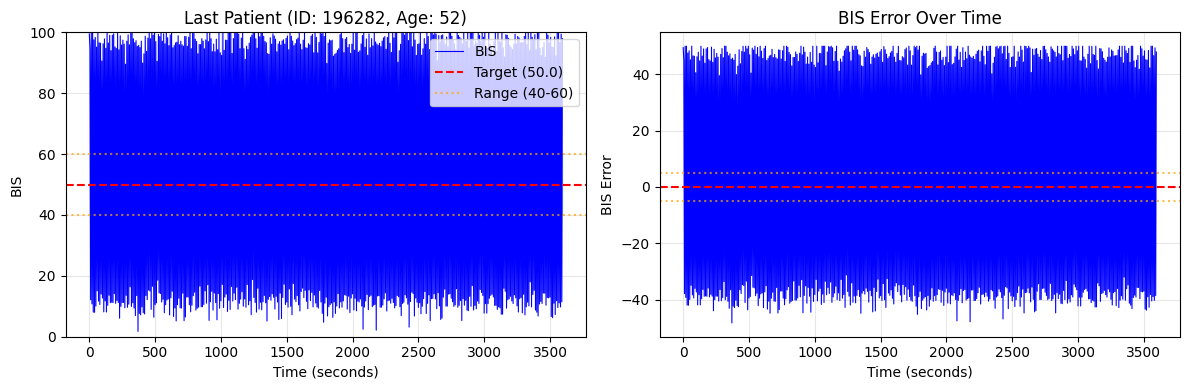


Last episode plot saved to images/dqn_last_episode_plot.png


In [ ]:
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

print(f"\n1. Loading patient data from {DATA_PATH}...")
df = load_data(DATA_PATH)
df = preprocess_data(df)
print(f"   Loaded {len(df)} patients")

print(f"\n2. Sampling {EVAL_SAMPLE_SIZE} patients...")
sample_df = df.sample(n=min(EVAL_SAMPLE_SIZE, len(df)), random_state=RANDOM_SEED)
print(f"   Sampled {len(sample_df)} patients")

print("\n3. Generating Schnider PK/PD parameters...")
eval_df = generate_schnider_dataset(sample_df)
print(f"   Generated parameters for {len(eval_df)} patients")

evaluator = DQNEvaluator(agent)

print(f"\n4. Evaluating policy at {len(EVAL_EPISODE_LENGTHS)} episode lengths...")
patient_results = []

for idx, (_, patient) in enumerate(eval_df.iterrows()):
    if (idx + 1) % 50 == 0:
        print(f"   Processing patient {idx + 1}/{len(eval_df)}...")

    patient_id = patient["PatientID"]
    age = patient["AgeCategory"]
    age_group = get_age_group(age, AGE_GROUPS)

    results = {}
    for ep_len in EVAL_EPISODE_LENGTHS:
        bis_traj = evaluator.simulate(patient, ep_len)
        metrics = calculate_bis_metrics(bis_traj, BIS_TARGET)
        results[ep_len] = metrics

    patient_results.append(
        {
            "patient_id": patient_id,
            "age": age,
            "age_group": age_group,
            "results": results,
        }
    )

results_df = create_results_dataframe(patient_results, EVAL_EPISODE_LENGTHS)
summary_df = create_summary_by_age_group(results_df, EVAL_EPISODE_LENGTHS, AGE_GROUPS)

print("\n5. Saving evaluation results...")
save_evaluation_results(
    results_df,
    summary_df,
    "dqn_direct_bis_delta_bis_error",
    str(METRICS_DIR),
)

print("\n" + "=" * 70)
print("Evaluation complete!")
print(f"  - Results: {len(results_df)} patients")
print(f"  - Age groups: {results_df['AgeGroup'].nunique()}")
print(f"  - Episode lengths: {EVAL_EPISODE_LENGTHS}")
print("=" * 70)

print("\n--- Summary Statistics (3600s episodes) ---")
print(results_df[['MDPE_3600s', 'MDAPE_3600s', 'Wobble_3600s', 'TimeInTarget_3600s']].describe())

print("\n--- Last Episode BIS Trajectory ---")
last_patient = eval_df.iloc[-1]
bis_traj_last = evaluator.simulate(last_patient, 3600)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
time_steps = np.arange(len(bis_traj_last)) * SIMULATION_STEP_SECONDS
plt.plot(time_steps, bis_traj_last, 'b-', linewidth=0.8, label='BIS')
plt.axhline(y=BIS_TARGET, color='r', linestyle='--', label=f'Target ({BIS_TARGET})')
plt.axhline(y=BIS_TARGET_RANGE[0], color='orange', linestyle=':', alpha=0.7, label=f'Range ({BIS_TARGET_RANGE[0]}-{BIS_TARGET_RANGE[1]})')
plt.axhline(y=BIS_TARGET_RANGE[1], color='orange', linestyle=':', alpha=0.7)
plt.fill_between(time_steps, BIS_TARGET_RANGE[0], BIS_TARGET_RANGE[1], alpha=0.1, color='green')
plt.xlabel('Time (seconds)')
plt.ylabel('BIS')
plt.title(f'Last Patient (ID: {last_patient["PatientID"]}, Age: {last_patient["AgeCategory"]})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0, 100)

plt.subplot(1, 2, 2)
error_traj = bis_traj_last - BIS_TARGET
plt.plot(time_steps, error_traj, 'b-', linewidth=0.8)
plt.axhline(y=0, color='r', linestyle='--')
plt.axhline(y=5, color='orange', linestyle=':', alpha=0.7)
plt.axhline(y=-5, color='orange', linestyle=':', alpha=0.7)
plt.xlabel('Time (seconds)')
plt.ylabel('BIS Error')
plt.title('BIS Error Over Time')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('images/dqn_last_episode_plot.png', dpi=100)
plt.show()
print("\nLast episode plot saved to images/dqn_last_episode_plot.png")

# LOAD AND EVALUATE SAVED DQN AGENT

In [ ]:
# Load saved agent
checkpoint = torch.load(DQN_PATH, weights_only=False)
agent = DQNAgent(lr=LR, gamma=GAMMA, epsilon=EPSILON_END)
agent.q_network.load_state_dict(checkpoint['q_network'])
agent.target_network.load_state_dict(checkpoint['target_network'])
agent.epsilon = checkpoint['epsilon']
ACTIONS = checkpoint['actions']
NUM_ACTIONS = len(ACTIONS)

print(f"Loaded agent with epsilon={agent.epsilon:.4f}")

# Run evaluation
evaluator = DQNEvaluator(agent)

print(f"\n1. Loading patient data from {DATA_PATH}...")
df = load_data(DATA_PATH)
df = preprocess_data(df)
sample_df = df.sample(n=min(100, len(df)), random_state=RANDOM_SEED)
eval_df = generate_schnider_dataset(sample_df)

print(f"\n2. Evaluating {len(eval_df)} patients...")
patient_results = []

for _, patient in eval_df.iterrows():
    patient_id = patient["PatientID"]
    age = patient["AgeCategory"]
    age_group = get_age_group(age, AGE_GROUPS)
    
    bis_traj = evaluator.simulate(patient, 3600)
    metrics = calculate_bis_metrics(bis_traj, BIS_TARGET)
    
    patient_results.append({
        "patient_id": patient_id,
        "age": age,
        "age_group": age_group,
        "results": {3600: metrics},
    })

results_df = create_results_dataframe(patient_results, [3600])
print("\nEvaluation Results (60 min episodes):")
print(results_df[['MDPE_3600s', 'MDAPE_3600s', 'Wobble_3600s', 'TimeInTarget_3600s']].describe())

Loaded agent with epsilon=0.0100

1. Loading patient data from data\Patients Data.csv...

2. Evaluating 100 patients...

Evaluation Results (60 min episodes):
       MDPE_3600s  MDAPE_3600s  Wobble_3600s  TimeInTarget_3600s
count  100.000000   100.000000    100.000000               100.0
mean    78.206835    86.271725     21.793165                 0.0
std      1.717541     0.423073      1.717541                 0.0
min     73.916736    85.523911     18.000274                 0.0
25%     77.268017    85.913055     20.691459                 0.0
50%     78.488106    86.308143     21.511894                 0.0
75%     79.308541    86.544320     22.731983                 0.0
max     81.999726    87.370864     26.083264                 0.0
